# Cargar y Procesar los Resultados

In [1]:
import chess.pgn
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
# Asegúrate de que esta ruta apunte a tu archivo PGN del torneo
TORNEO_PGN_PATH = "../torneo_gauntlet_final.pgn" # <-- ¡Verificá este nombre!
# --------------------

print(f"Cargando partidas desde: {TORNEO_PGN_PATH}")

partidas_data = []
pgn_file = open(TORNEO_PGN_PATH)

# Leemos cada partida del archivo PGN
while True:
    partida = chess.pgn.read_game(pgn_file)
    if partida is None:
        break # Terminamos cuando no hay más partidas

    # Extraemos la información que nos interesa de cada partida
    partidas_data.append({
        "white_player": partida.headers["White"],
        "black_player": partida.headers["Black"],
        "result": partida.headers["Result"]
    })

print(f"✅ Se cargaron {len(partidas_data)} partidas.")

# Convertimos la lista de datos a un DataFrame de Pandas
df_resultados = pd.DataFrame(partidas_data)

# Mostramos las primeras 5 filas para verificar que se cargó bien
print("\nPrimeras 5 partidas del torneo:")
df_resultados.head()

Cargando partidas desde: ../torneo_gauntlet_final.pgn
✅ Se cargaron 700 partidas.

Primeras 5 partidas del torneo:


,white_player,black_player,result
0,BotAjedrezLSTM,Stockfish-Skill-0,0-1
1,Stockfish-Skill-0,BotAjedrezLSTM,1-0
2,BotAjedrezLSTM,Stockfish-Skill-0,0-1
3,Stockfish-Skill-0,BotAjedrezLSTM,1-0
4,BotAjedrezLSTM,Stockfish-Skill-0,0-1


# Análisis Estadístico

In [6]:
import os
import tensorflow as tf
import pickle
import chess.pgn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURACIÓN ---
# La ruta a la carpeta donde guardaste tus modelos y el tokenizador
MODELOS_DIR = "../trained_models/"
# La ruta al archivo PGN con los resultados de tu torneo Gauntlet
TORNEO_PGN_PATH = "../torneo_gauntlet_final.pgn" # <-- ¡Verificá este nombre!
# El modelo específico que usaremos para este análisis
MODELO_A_ANALIZAR = "modelo_epoch_07.keras" # <-- El que elegimos como el mejor

MAX_SEQUENCE_LENGTH = 50
MODEL_PATH = os.path.join(MODELOS_DIR, MODELO_A_ANALIZAR)
TOKENIZER_PATH = os.path.join(MODELOS_DIR, "tokenizer.pkl")
# --------------------

# --- 2. CARGA DE ARTEFACTOS ---
print("Cargando artefactos...")
# Cargar el tokenizador
with open(TOKENIZER_PATH, 'rb') as f:
    tokenizer = pickle.load(f)

# Cargar el modelo
modelo_final = tf.keras.models.load_model(MODEL_PATH)
print(f"✅ Modelo '{MODELO_A_ANALIZAR}' y tokenizador cargados.")

# --- 3. FUNCIÓN DE PREDICCIÓN ---
def predecir_siguientes_movimientos(model, tokenizer, sequence_text, top_k=5):
    sequence_num = tokenizer.texts_to_sequences([sequence_text])
    sequence_padded = tf.keras.preprocessing.sequence.pad_sequences(
        sequence_num, maxlen=MAX_SEQUENCE_LENGTH, padding='post'
    )
    prediction = model.predict(sequence_padded, verbose=0)[0]
    top_indices = np.argsort(prediction)[-top_k:][::-1]
    predicted_moves = [tokenizer.index_word.get(i, "[DESCONOCIDO]") for i in top_indices]
    return predicted_moves

# --- 4. BUCLE PRINCIPAL DE EVALUACIÓN ---
resultados_partidas = []

print(f"\n--- Analizando las partidas de: {os.path.basename(TORNEO_PGN_PATH)} ---")
pgn_file = open(TORNEO_PGN_PATH)

game_count = 0
while True:
    try:
        partida = chess.pgn.read_game(pgn_file)
        if partida is None:
            break
    except Exception as e:
        print(f"Error leyendo una partida, saltando a la siguiente. Error: {e}")
        continue
    
    game_count += 1
    if game_count % 100 == 0:
        print(f"Procesando partida {game_count}...")

    bot_color = None
    if partida.headers["White"] == "BotAjedrezLSTM":
        bot_color = chess.WHITE
    elif partida.headers["Black"] == "BotAjedrezLSTM":
        bot_color = chess.BLACK
    
    if bot_color is None:
        continue

    board = partida.board()
    historial_san = []
    
    for i, move in enumerate(partida.mainline_moves()):
        if board.turn == bot_color:
            jugada_correcta = board.san(move)
            predicciones = predecir_siguientes_movimientos(modelo_final, tokenizer, historial_san, top_k=5)
            
            resultados_partidas.append({
                "num_jugada": (i // 2) + 1,
                "acierto_top1": 1 if jugada_correcta == predicciones[0] else 0,
                "acierto_top5": 1 if jugada_correcta in predicciones else 0
            })
        
        historial_san.append(board.san(move))
        board.push(move)

pgn_file.close()
print("\n✅ Análisis estadístico completado.")

Cargando artefactos...
✅ Modelo 'modelo_epoch_07.keras' y tokenizador cargados.

--- Analizando las partidas de: torneo_gauntlet_final.pgn ---
Procesando partida 100...
Procesando partida 200...
Procesando partida 300...
Procesando partida 400...
Procesando partida 500...
Procesando partida 600...
Procesando partida 700...

✅ Análisis estadístico completado.


El Gráfico de Rendimiento


--- Generando Gráfico de Rendimiento Final ---


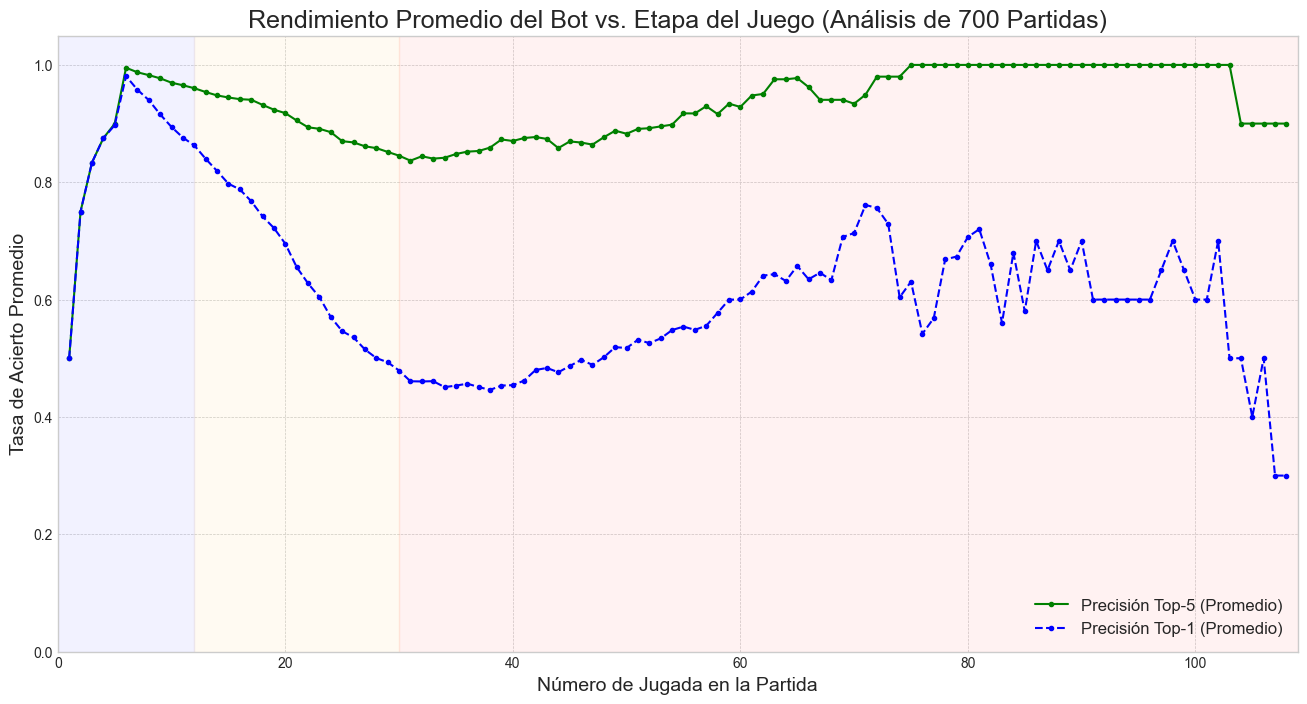

In [7]:
# Convertimos la lista de resultados a un DataFrame de Pandas para un manejo fácil
df_stats = pd.DataFrame(resultados_partidas)

# Agrupamos por número de jugada y calculamos la precisión promedio para cada una
df_rendimiento = df_stats.groupby('num_jugada').mean().reset_index()

# Usamos una media móvil para suavizar las curvas y ver la tendencia general
window_size = 5 # Puedes ajustar este número para suavizar más (ej. 10) o menos (ej. 3)
df_rendimiento['top1_suavizado'] = df_rendimiento['acierto_top1'].rolling(window=window_size, min_periods=1).mean()
df_rendimiento['top5_suavizado'] = df_rendimiento['acierto_top5'].rolling(window=window_size, min_periods=1).mean()

# --- Creación del Gráfico Final ---
print("\n--- Generando Gráfico de Rendimiento Final ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df_rendimiento['num_jugada'], df_rendimiento['top5_suavizado'], label='Precisión Top-5 (Promedio)', marker='.', linestyle='-', color='green')
ax.plot(df_rendimiento['num_jugada'], df_rendimiento['top1_suavizado'], label='Precisión Top-1 (Promedio)', marker='.', linestyle='--', color='blue')

# Títulos y etiquetas
ax.set_title('Rendimiento Promedio del Bot vs. Etapa del Juego (Análisis de 700 Partidas)', fontsize=18)
ax.set_xlabel('Número de Jugada en la Partida', fontsize=14)
ax.set_ylabel('Tasa de Acierto Promedio', fontsize=14)
ax.set_xlim(0, max(df_rendimiento['num_jugada']) + 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Añadir líneas verticales para marcar las fases del juego (Apertura, Medio Juego, Final)
ax.axvspan(0, 12, color='blue', alpha=0.05, label='Apertura')
ax.axvspan(12, 30, color='orange', alpha=0.05, label='Medio Juego')
ax.axvspan(30, max(df_rendimiento['num_jugada']) + 1, color='red', alpha=0.05, label='Final')

plt.show()